# 2 — What each constraint costs

Notebook 1 produced a €11.2 M optimum that puts one variety in 21 of 24
greenhouses and needs 931 pickers in a single week. Here each operational
constraint is swept across a range to produce a trade-off curve, which is the
output a planner can actually use.

In [1]:
import sys
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append("../src")
from model import enumerate_options, load_data, solve_plan, weekly_labour_profile

FIGURES = "../reports/figures"
plt.style.use("seaborn-v0_8-whitegrid")

data = load_data("../data")
options = enumerate_options(data)
base = solve_plan(options, data)
BASE_PROFIT = base.profit
print(f"reference profit € {BASE_PROFIT:,.2f}")

reference profit € 11,206,575.00


## 1. Production ceiling

Caps total season output, standing in for limited market demand or packhouse
throughput.

In [2]:
caps = [1_200_000, 1_000_000, 900_000, 800_000, 700_000, 600_000, 500_000, 450_000, 400_000]
rows = []
for cap in caps:
    r = solve_plan(options, data, production_cap=cap)
    rows.append({"cap_kg": cap, "status": r.status,
                 "profit": r.profit, "loss_%": 100 * (1 - r.profit / BASE_PROFIT) if r.feasible else None})

production_sweep = pd.DataFrame(rows)
print(production_sweep.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

 cap_kg  status        profit  loss_%
1200000 Optimal 11,206,575.00    0.00
1000000 Optimal 11,206,575.00    0.00
 900000 Optimal 11,206,575.00    0.00
 800000 Optimal 10,974,575.00    2.07
 700000 Optimal  9,953,775.00   11.18
 600000 Optimal  8,932,975.00   20.29
 500000 Optimal  7,696,437.50   31.32
 450000 Optimal  4,560,730.00   59.30
 400000 Optimal    565,270.00   94.96


The cap is slack above roughly 825,000 kg, which is what the unconstrained
plan produces. Below that, profit erodes gently to about 500,000 kg and then
collapses: at 400,000 kg the farm loses nearly everything, because the only
plans that fit are ones whose yields are too low to cover the fixed per-hectare
establishment cost.

That cliff is the useful part. It says the farm has very little room to shrink
output before the economics invert.

## 2. Agronomic risk ceiling

`Risque/10` scores each scenario. Here the *mean* score across the 24
greenhouses is capped, which lets the model mix a risky high-yield scenario
with safer ones rather than banning anything outright.

In [3]:
rows = []
for limit in [8, 7, 6, 5.5, 5, 4.5, 4, 3.5, 3]:
    r = solve_plan(options, data, max_avg_risk=limit)
    rows.append({"max_avg_risk": limit, "profit": r.profit,
                 "loss_%": 100 * (1 - r.profit / BASE_PROFIT),
                 "scenarios": ", ".join(str(s) for s in sorted(r.plan.scenario.unique())),
                 "achieved_risk": round(r.avg_risk, 2)})

risk_sweep = pd.DataFrame(rows)
print(risk_sweep.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

 max_avg_risk        profit  loss_% scenarios  achieved_risk
         8.00 11,206,575.00    0.00     5, 15           5.38
         7.00 11,206,575.00    0.00     5, 15           5.38
         6.00 11,206,575.00    0.00     5, 15           5.38
         5.50 11,206,575.00    0.00     5, 15           5.38
         5.00 11,197,575.00    0.08        15           5.00
         4.50 10,513,175.00    6.19    15, 19           4.50
         4.00  9,619,975.00   14.16    15, 19           4.00
         3.50  8,668,775.00   22.65    15, 19           3.50
         3.00  7,566,775.00   32.48        19           3.00


The unconstrained plan sits at a mean risk of 5.38. Pulling that down to 5.0
costs about €9,000 — under a tenth of a percent. Below that the price rises
steeply: 4.0 costs roughly 14% of profit and 3.0 costs around 32%.

There is a free lunch at the top of this curve and the base model walks past
it.

## 3. Harvest labour ceiling

The binding constraint on most real berry operations. Yield per hectare per
week is converted to pickers using the per-scenario labour speed from
`Charges_var.csv`, assuming a six-day harvest week, and the crew needed in the
*busiest* week is capped.

These solves are harder than the others, because the labour constraint couples
every greenhouse through shared harvest weeks. A 1% relative MIP gap keeps
the sweep tractable and sits well inside the precision of the yield forecasts.

In [4]:
rows = []
for crew in [900, 800, 700, 600, 500, 400, 300, 250, 200]:
    r = solve_plan(options, data, max_peak_labour=crew, gap=0.01, time_limit=60)
    rows.append({"max_pickers": crew, "profit": r.profit,
                 "loss_%": 100 * (1 - r.profit / BASE_PROFIT),
                 "actual_peak": round(r.peak_pickers),
                 "n_scenarios": r.plan.scenario.nunique()})

labour_sweep = pd.DataFrame(rows)
print(labour_sweep.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))

 max_pickers        profit  loss_%  actual_peak  n_scenarios
         900 11,090,575.00    1.04          899            3
         800 10,730,975.00    4.24          797            3
         700 10,382,975.00    7.35          699            3
         600 10,023,375.00   10.56          597            3
         500  9,620,125.00   14.16          500            3
         400  8,676,305.00   22.58          399            5
         300  7,740,937.50   30.93          300            5
         250  7,156,362.50   36.14          249            6
         200  3,414,417.50   69.53          200           11


This is the constraint that changes the *shape* of the answer, not just its
value. The unconstrained plan uses 2 scenarios; at a 400-picker cap it uses 5,
and at 200 it uses 11.

The reason is staggering. To harvest with a smaller crew the farm has to spread
planting across different scenarios and weeks so the harvest peaks do not
coincide. Diversification is not something the model has to be told to value —
it falls out of the labour constraint once labour is represented at all.

The monoculture in notebook 1 was never an agronomic recommendation. It was an
artefact of pretending labour is free and infinite.

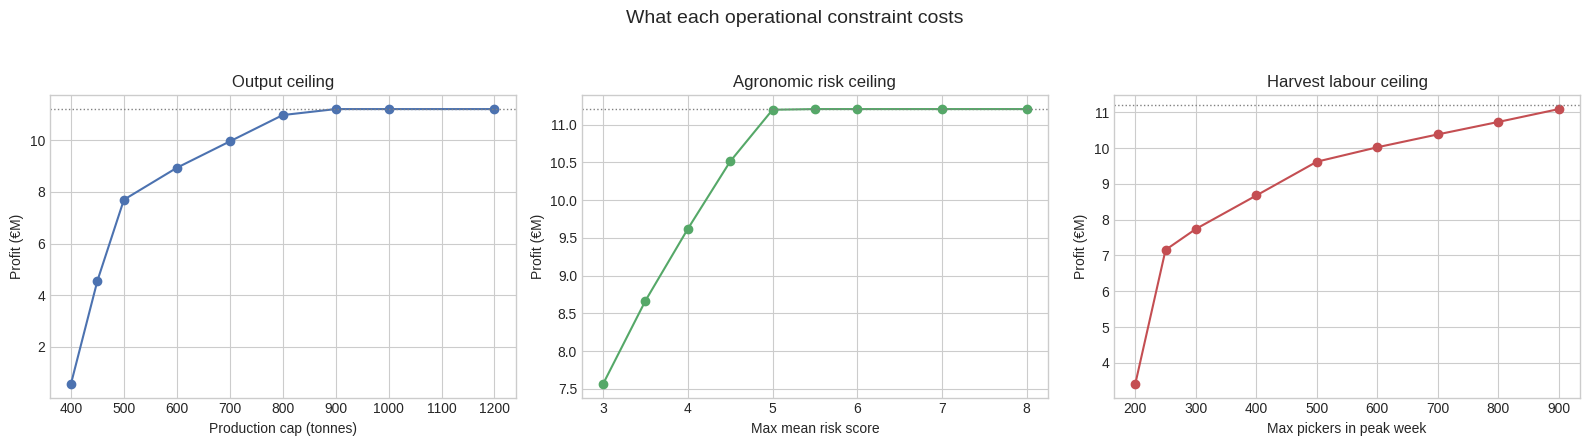

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

feasible = production_sweep.dropna(subset=["profit"])
axes[0].plot(feasible.cap_kg / 1000, feasible.profit / 1e6, "o-", color="#4C72B0")
axes[0].set_xlabel("Production cap (tonnes)")
axes[0].set_title("Output ceiling")

axes[1].plot(risk_sweep.max_avg_risk, risk_sweep.profit / 1e6, "o-", color="#55A868")
axes[1].set_xlabel("Max mean risk score")
axes[1].set_title("Agronomic risk ceiling")

axes[2].plot(labour_sweep.max_pickers, labour_sweep.profit / 1e6, "o-", color="#C44E52")
axes[2].set_xlabel("Max pickers in peak week")
axes[2].set_title("Harvest labour ceiling")

for ax in axes:
    ax.axhline(BASE_PROFIT / 1e6, ls=":", color="grey", lw=1)
    ax.set_ylabel("Profit (€M)")

fig.suptitle("What each operational constraint costs", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(f"{FIGURES}/tradeoff_frontiers.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Smoothing the harvest

Comparing the labour profile under a 400-picker cap against the unconstrained
spike shows what the constraint buys operationally.

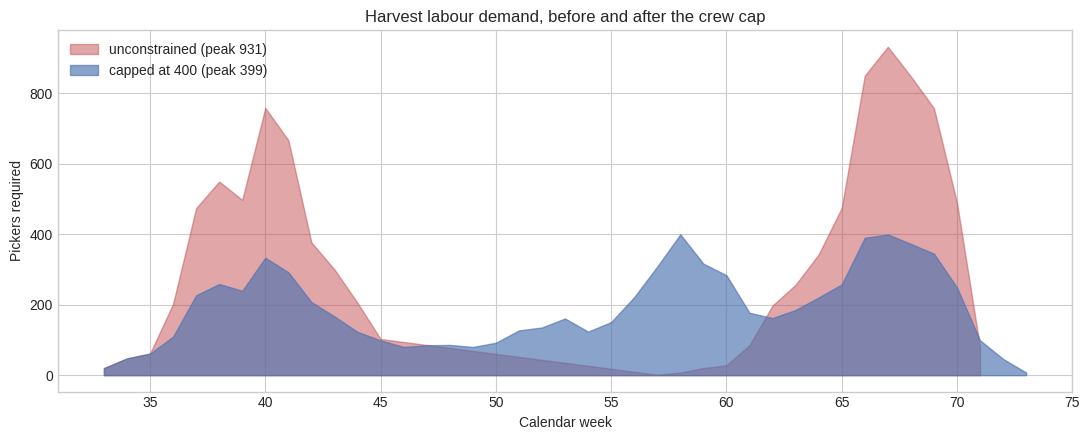

unconstrained: 28 harvest weeks, peak 931
capped:        41 harvest weeks, peak 399
profit cost of the cap: € 2,530,270 (22.6%)


In [6]:
capped = solve_plan(options, data, max_peak_labour=400, gap=0.01, time_limit=60)
profile_base = weekly_labour_profile(base, options)
profile_capped = weekly_labour_profile(capped, options)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.fill_between(profile_base.index, profile_base.values, alpha=0.5,
                color="#C44E52", label=f"unconstrained (peak {profile_base.max():,.0f})")
ax.fill_between(profile_capped.index, profile_capped.values, alpha=0.65,
                color="#4C72B0", label=f"capped at 400 (peak {profile_capped.max():,.0f})")
ax.set_xlabel("Calendar week")
ax.set_ylabel("Pickers required")
ax.set_title("Harvest labour demand, before and after the crew cap")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES}/labour_profile_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"unconstrained: {(profile_base > 0).sum()} harvest weeks, peak {profile_base.max():,.0f}")
print(f"capped:        {(profile_capped > 0).sum()} harvest weeks, peak {profile_capped.max():,.0f}")
print(f"profit cost of the cap: € {BASE_PROFIT - capped.profit:,.0f} "
      f"({100 * (1 - capped.profit / BASE_PROFIT):.1f}%)")

## 5. Sector-wide uniformity

Forcing every greenhouse in a sector onto the same scenario, to simplify
supervision and machinery movements.

In [7]:
uniform = solve_plan(options, data, sector_uniform=True)
print(f"uniform:       € {uniform.profit:,.2f}")
print(f"unconstrained: € {BASE_PROFIT:,.2f}")
print(f"cost:          € {BASE_PROFIT - uniform.profit:,.2f}")

uniform:       € 11,206,575.00
unconstrained: € 11,206,575.00
cost:          € 0.00


Free. The unconstrained optimum is already sector-uniform, so the constraint
never binds and nothing is given up by imposing it. Worth knowing: it is an
operational simplification the farm can adopt at no cost.

## 6. A plan worth proposing

Each constraint has been priced separately. Combining the two that matter —
a realistic crew and a lower risk exposure — gives a plan a manager could
defend.

In [8]:
candidates = {
    "Unconstrained optimum": dict(),
    "Risk ≤ 5.0": dict(max_avg_risk=5.0),
    "Crew ≤ 500": dict(max_peak_labour=500, gap=0.01, time_limit=60),
    "Crew ≤ 500, risk ≤ 5.0": dict(max_peak_labour=500, max_avg_risk=5.0, gap=0.01, time_limit=60),
    "Crew ≤ 400, risk ≤ 4.5": dict(max_peak_labour=400, max_avg_risk=4.5, gap=0.01, time_limit=60),
}

rows = []
for label, kwargs in candidates.items():
    r = solve_plan(options, data, **kwargs)
    rows.append({"plan": label, "status": r.status,
                 "profit_€M": round(r.profit / 1e6, 3) if r.feasible else None,
                 "loss_%": round(100 * (1 - r.profit / BASE_PROFIT), 2) if r.feasible else None,
                 "peak_crew": round(r.peak_pickers) if r.feasible else None,
                 "mean_risk": round(r.avg_risk, 2) if r.feasible else None,
                 "varieties": r.plan.scenario.nunique() if r.feasible else None})

pd.DataFrame(rows).to_string(index=False)
print(pd.DataFrame(rows).to_string(index=False))

                  plan  status  profit_€M  loss_%  peak_crew  mean_risk  varieties
 Unconstrained optimum Optimal     11.207    0.00        931       5.38          2
            Risk ≤ 5.0 Optimal     11.198    0.08       1025       5.00          1
            Crew ≤ 500 Optimal      9.620   14.16        500       4.54          3
Crew ≤ 500, risk ≤ 5.0 Optimal      9.620   14.16        500       4.54          3
Crew ≤ 400, risk ≤ 4.5 Optimal      8.422   24.85        400       4.50          4


## Conclusions

1. **The headline optimum is not a plan.** €11.2 M assumes an unlimited harvest
   crew available for a few weeks and the entire farm on one variety.
2. **Risk reduction is nearly free at the margin.** Mean risk drops from 5.38 to
   5.0 for under 0.1% of profit. Any manager would take that trade.
3. **Labour capacity is the real driver of farm structure.** It is the only
   constraint here that forces variety and planting-week diversification, and it
   does so without being asked.
4. **Sector uniformity is free**, so it should simply be adopted.
5. **There is little room to shrink output.** Below roughly 500,000 kg the
   economics invert, because establishment costs are per hectare and do not
   scale down with yield.

### Limitations

- Risk scores are an ordinal 3–10 judgement from the source data. Averaging
  ordinal scores is a convenience, not a defensible risk measure; a proper
  treatment would model correlated loss scenarios.
- Prices are deterministic. Since planting-week choice is essentially a bet on
  the price curve, a stochastic or robust formulation would be the right next
  step.
- Labour uses a flat six-day harvest week and ignores travel, training and
  availability.
- Scenario 14 is excluded by a sentinel cost in the source data rather than by
  a real constraint.